In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/datalab_export_2026-05-28 23_09_12.csv')

In [4]:
df

,index,is_canceled,lead_time,arrival_date_week_number,arrival_date_day_of_month,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,deposit_type_No_Deposit,deposit_type_Non_Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,1,0,342,27,1,7,0,0,2,0,...,0,0,0,1,0,0,0,0,1,0
1,2,0,737,27,1,7,0,0,2,0,...,0,0,0,1,0,0,0,0,1,0
2,3,0,7,27,1,7,0,1,1,0,...,0,0,0,1,0,0,0,0,1,0
3,4,0,13,27,1,7,0,1,1,0,...,0,0,0,1,0,0,0,0,1,0
4,5,0,14,27,1,7,0,2,2,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,1,72,27,3,7,0,2,2,0,...,0,0,0,1,0,0,0,0,1,0
96,97,1,63,27,3,7,2,5,2,0,...,0,0,0,1,0,0,0,0,1,0
97,98,0,63,27,3,7,2,5,3,0,...,0,0,0,1,0,0,0,0,1,0
98,99,0,101,27,3,7,2,5,2,1,...,0,0,0,1,0,0,0,0,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   index                           100 non-null    int64  
 1   is_canceled                     100 non-null    int64  
 2   lead_time                       100 non-null    int64  
 3   arrival_date_week_number        100 non-null    int64  
 4   arrival_date_day_of_month       100 non-null    int64  
 5   arrival_date_month              100 non-null    int64  
 6   stays_in_weekend_nights         100 non-null    int64  
 7   stays_in_week_nights            100 non-null    int64  
 8   adults                          100 non-null    int64  
 9   children                        100 non-null    int64  
 10  babies                          100 non-null    int64  
 11  is_repeated_guest               100 non-null    int64  
 12  previous_cancellations          100 n

/tmp/ipykernel_1623/3644507763.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_canceled', data=df, ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_1623/3644507763.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Ləğv Edilməyib (0)', 'Ləğv Edilib (1)'])
/tmp/ipykernel_1623/3644507763.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_canceled', y='avg_daily_rate', data=df, ax=axes[1, 0], palette='Set1')
/tmp/ipykernel_1623/3644507763.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedL

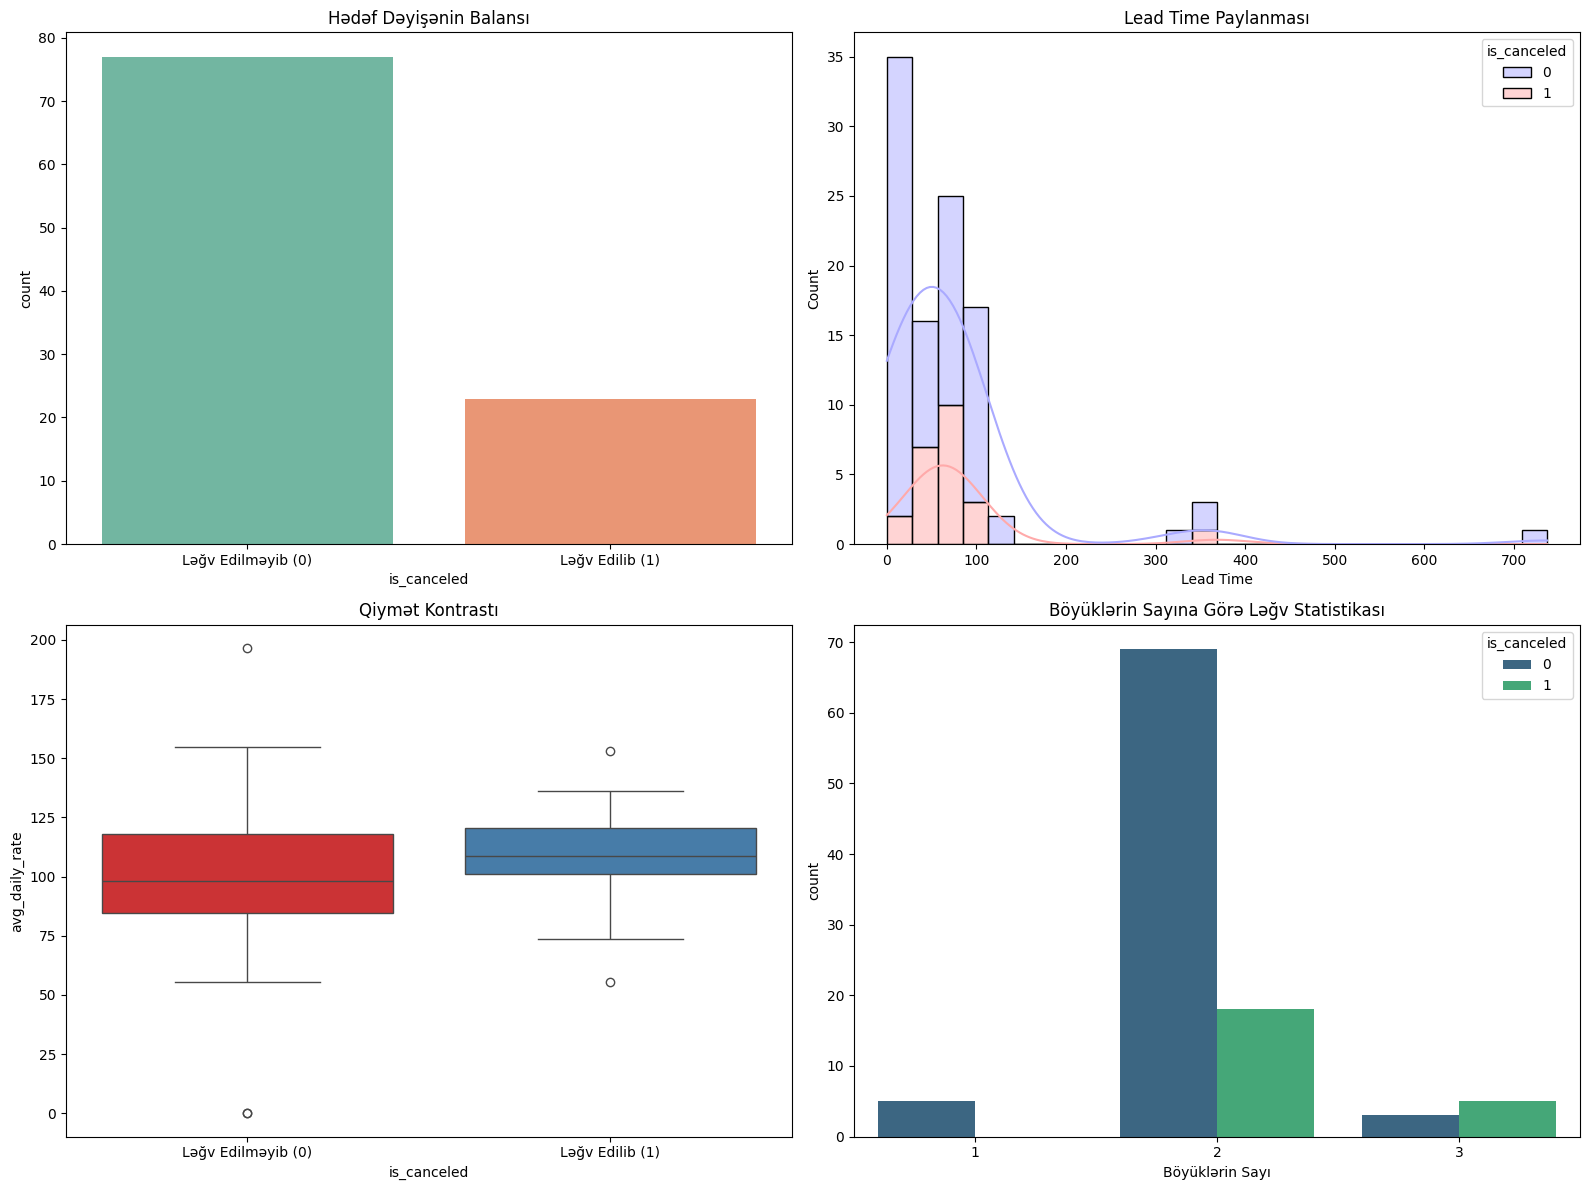

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(x='is_canceled', data=df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Hədəf Dəyişənin Balansı')
axes[0, 0].set_xticklabels(['Ləğv Edilməyib (0)', 'Ləğv Edilib (1)'])

sns.histplot(data=df, x='lead_time', hue='is_canceled', kde=True, ax=axes[0, 1], palette='bwr', multiple='stack')
axes[0, 1].set_title('Lead Time Paylanması')
axes[0, 1].set_xlabel('Lead Time')

sns.boxplot(x='is_canceled', y='avg_daily_rate', data=df, ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Qiymət Kontrastı')
axes[1, 0].set_xticklabels(['Ləğv Edilməyib (0)', 'Ləğv Edilib (1)'])

sns.countplot(x='adults', hue='is_canceled', data=df, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Böyüklərin Sayına Görə Ləğv Statistikası')
axes[1, 1].set_xlabel('Böyüklərin Sayı')

plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
X = df.drop(columns=['index', 'is_canceled'])
y = df['is_canceled']

In [9]:
zero_variance_cols = X.columns[X.std() == 0]
if len(zero_variance_cols) > 0:
  X = X.drop(columns=zero_variance_cols)
  print(zero_variance_cols.tolist())

['arrival_date_week_number', 'arrival_date_month', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'hotel_City', 'hotel_Resort', 'meal_No_meal', 'market_segment_Aviation', 'market_segment_Complementary', 'market_segment_Groups', 'market_segment_Undefined', 'distribution_channel_GDS', 'distribution_channel_Undefined', 'reserved_room_type_B', 'reserved_room_type_L', 'deposit_type_No_Deposit', 'deposit_type_Non_Refund', 'deposit_type_Refundable', 'customer_type_Group']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
X_train.shape

(80, 31)

In [13]:
X_test.shape

(20, 31)

In [14]:
scaler = StandardScaler()

In [15]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
X_train_scaled[0][:5]

array([-0.80698185, -1.20992049, -0.84815127,  0.08972752, -0.14285714])

In [21]:
df.head()

,index,is_canceled,lead_time,arrival_date_week_number,arrival_date_day_of_month,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L,deposit_type_No_Deposit,deposit_type_Non_Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,1,0,342,27,1,7,0,0,2,0,...,0,0,0,1,0,0,0,0,1,0
1,2,0,737,27,1,7,0,0,2,0,...,0,0,0,1,0,0,0,0,1,0
2,3,0,7,27,1,7,0,1,1,0,...,0,0,0,1,0,0,0,0,1,0
3,4,0,13,27,1,7,0,1,1,0,...,0,0,0,1,0,0,0,0,1,0
4,5,0,14,27,1,7,0,2,2,0,...,0,0,0,1,0,0,0,0,1,0


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [23]:
lr = LogisticRegression(random_state=42)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

lr.fit(X_train_scaled, y_train)

dt.fit(X_train_scaled, y_train)

rf.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [27]:
predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for model_name, y_pred in predictions.items():
    print(f"{model_name} Modelinin Metrikaları:")

    acc = accuracy_score(y_test, y_pred)
    print(f"Ümumi Dəqiqlik (Accuracy): {acc:.2f}\n")

    print("Confusion Matrix (Qarışıqlıq Matrisi):")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print()

    print("Klassifikasiya Hesabatı:")
    print(classification_report(y_test, y_pred, target_names=['Ləğv Edilməyib (0)', 'Ləğv Edilib (1)']))


Logistic Regression Modelinin Metrikaları:
Ümumi Dəqiqlik (Accuracy): 0.75

Confusion Matrix (Qarışıqlıq Matrisi):
[[14  1]
 [ 4  1]]

Klassifikasiya Hesabatı:
                    precision    recall  f1-score   support

Ləğv Edilməyib (0)       0.78      0.93      0.85        15
   Ləğv Edilib (1)       0.50      0.20      0.29         5

          accuracy                           0.75        20
         macro avg       0.64      0.57      0.57        20
      weighted avg       0.71      0.75      0.71        20

Decision Tree Modelinin Metrikaları:
Ümumi Dəqiqlik (Accuracy): 0.85

Confusion Matrix (Qarışıqlıq Matrisi):
[[14  1]
 [ 2  3]]

Klassifikasiya Hesabatı:
                    precision    recall  f1-score   support

Ləğv Edilməyib (0)       0.88      0.93      0.90        15
   Ləğv Edilib (1)       0.75      0.60      0.67         5

          accuracy                           0.85        20
         macro avg       0.81      0.77      0.78        20
      weighted avg   

In [29]:
importances = rf.feature_importances_
features = X.columns

indices = np.argsort(importances)[::-1][:10]

/tmp/ipykernel_1623/3112108274.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette="viridis")


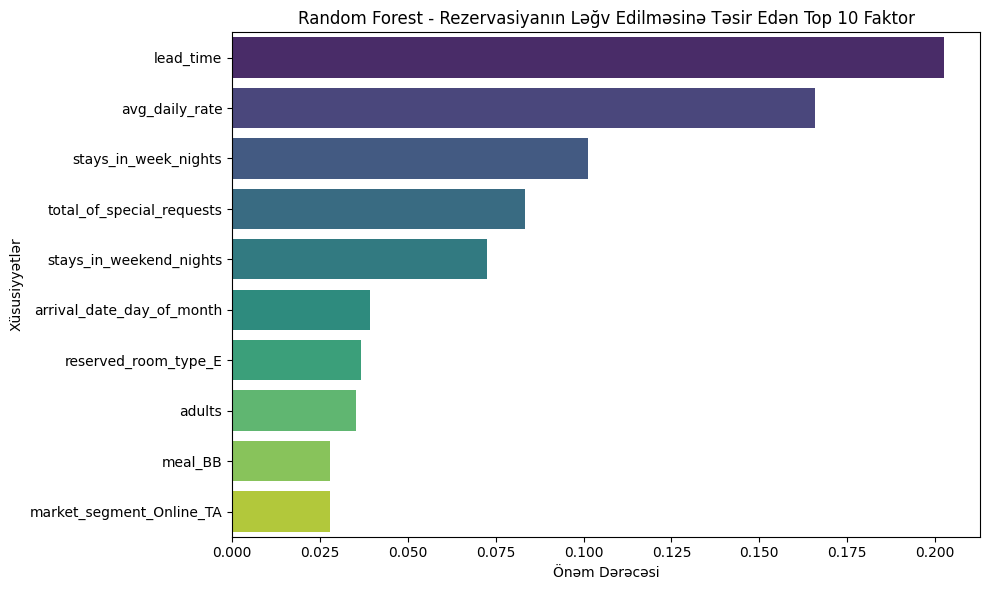

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=features[indices], palette="viridis")
plt.title("Random Forest - Rezervasiyanın Ləğv Edilməsinə Təsir Edən Top 10 Faktor")
plt.xlabel("Önəm Dərəcəsi")
plt.ylabel("Xüsusiyyətlər")
plt.tight_layout()

plt.show()